# 矩阵求导与梯度核对

学习目标：从逐元素偏导推出向量与矩阵平方误差的梯度，明确公式的形状和参数条件，并用有限差分与 SciPy 检查自己的实现。

前置知识：内积、矩阵乘法与转置、Frobenius 范数、迹、偏导数和链式法则；Python 函数与 NumPy 数组操作。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 先分清函数值与梯度的形状

### 1.1 标量对向量求导

取 $x=(x_1,x_2)^T\in\mathbb R^2$，定义标量函数 $f(x)=\tfrac12(x_1-2)^2+2(x_2+1)^2$。分别改变两个分量，得到偏导数 $\partial f/\partial x_1=x_1-2$ 与 $\partial f/\partial x_2=4(x_2+1)$。

本章把它们排成列向量，称为梯度（gradient）：

$$\nabla_x f(x)=\begin{bmatrix}\partial f/\partial x_1\\\vdots\\\partial f/\partial x_n\end{bmatrix}\in\mathbb R^n,\qquad f:\mathbb R^n\to\mathbb R.$$

若按“输出作行、输入作列”定义雅可比矩阵，标量函数的雅可比是 $J_f=(\nabla_x f)^T\in\mathbb R^{1\times n}$。两者包含相同偏导，但布局不同。代码通常用形状为 (n,) 的一维数组存梯度；数组转置不会把它自动变成 (n, 1)。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import check_grad

x = np.array([1.0, 1.0])
value = 0.5 * (x[0] - 2) ** 2 + 2 * (x[1] + 1) ** 2
gradient = np.array([x[0] - 2, 4 * (x[1] + 1)])

print("标量函数值：", value)  # 8.5。
print("梯度分量：", gradient)  # [-1, 8]。
print("一维数组与其转置的形状：", gradient.shape, gradient.T.shape)  # 都是 (2,)。
print("显式列向量与行雅可比：", gradient[:, None].shape, gradient[None, :].shape)  # 预期为 (2, 1) (1, 2)。

标量函数值： 8.5
梯度分量： [-1.  8.]
一维数组与其转置的形状： (2,) (2,)
显式列向量与行雅可比： (2, 1) (1, 2)


### 1.2 标量对矩阵求导

设 $F:\mathbb R^{p\times q}\to\mathbb R$，矩阵参数 $W$ 的各元素可以独立改变。本章定义同形矩阵梯度

$$G=\nabla_W F(W)\in\mathbb R^{p\times q},\qquad G_{ij}=\frac{\partial F}{\partial W_{ij}},\quad 1\leq i\leq p,\ 1\leq j\leq q.$$

例如 $F(W)=W_{11}^2+3W_{12}+W_{21}W_{22}$，其中 $W\in\mathbb R^{2\times2}$。固定其他元素，逐一求偏导，得到

$$\nabla_W F=\begin{bmatrix}2W_{11}&3\\W_{22}&W_{21}\end{bmatrix}.$$

这里输出是标量，梯度才可以与参数同形。若输出本身是向量或矩阵，其全部导数需要更多指标，不能直接沿用这张同形梯度表。

In [2]:
W = np.array([[1.0, 2.0], [-1.0, 3.0]])
value = W[0, 0] ** 2 + 3 * W[0, 1] + W[1, 0] * W[1, 1]
gradient = np.array([[2 * W[0, 0], 3], [W[1, 1], W[1, 0]]])
print("函数值：", value)  # 4。
print("梯度：\n", gradient)  # [[2, 3], [3, -1]]。
print("参数与梯度形状：", W.shape, gradient.shape)  # 都是 (2, 2)。

函数值： 4.0
梯度：
 [[ 2.  3.]
 [ 3. -1.]]
参数与梯度形状： (2, 2) (2, 2)


## 2 从内积与平方范数开始

### 2.1 固定系数的内积

设 $a,x\in\mathbb R^n$ 都是数学列向量，$a$ 固定，$x$ 是变量。内积 $f(x)=a^Tx=\sum_{i=1}^{n}a_ix_i$ 对第 $j$ 个分量求偏导时，只有 $a_jx_j$ 改变，因此

$$\frac{\partial f}{\partial x_j}=a_j,\qquad \nabla_x(a^Tx)=a.$$

例如 $a=(2,-3)^T$，只给 $x_2$ 增加 $h$，函数值就精确减少 $3h$。若 $a$ 也依赖 $x$，则不再满足“固定系数”的前提，需要对这条依赖一起求导。

In [3]:
a = np.array([2.0, -3.0])
x = np.array([1.0, 4.0])
change = np.array([0.0, 0.1])
print("内积：", a @ x)  # -10。
print("梯度：", a)  # [2, -3]。
print("实际变化与梯度预测：", a @ (x + change) - a @ x, a @ change)  # 预期约为 -0.3 -0.3。
# 两者都约为 -0.3；线性函数没有额外的高次误差。

内积： -10.0
梯度： [ 2. -3.]
实际变化与梯度预测： -0.29999999999999893 -0.30000000000000004


### 2.2 平方范数中的两个相同变量

平方范数 $s(x)=x^Tx=\sum_{i=1}^{n}x_i^2$ 中，两处 $x$ 都在变化。因此 $\nabla_x s=2x$，不能把其中一个 $x$ 当常量套用上一节结论。

对固定 $c\in\mathbb R^n$，有

$$f(x)=\frac12\|x-c\|_2^2=\frac12\sum_{i=1}^n(x_i-c_i)^2,
\qquad \nabla_x f=x-c.$$

前面的 $1/2$ 抵消了平方求导产生的 2。这个函数处处可导；若换成未平方的 $\|x-c\|_2$，梯度仅在 $x\ne c$ 时为 $(x-c)/\|x-c\|_2$，在 $x=c$ 处不可导。不要把长度、平方长度及半平方长度混用。

In [4]:
x = np.array([3.0, 4.0])
c = np.array([1.0, 1.0])
residual = x - c
print("平方范数与其梯度：", x @ x, 2 * x)  # 25 与 [6, 8]。
print("半平方距离：", 0.5 * (residual @ residual))  # 6.5。
print("半平方距离的梯度：", residual)  # [2, 3]。
print("在 x=c 时的半平方距离梯度：", c - c)  # 零向量，无需除以长度。

平方范数与其梯度： 25.0 [6. 8.]
半平方距离： 6.5
半平方距离的梯度： [2. 3.]
在 x=c 时的半平方距离梯度： [0. 0.]


### 2.3 二次型必须检查对称性

设 $A\in\mathbb R^{n\times n}$ 固定，$q(x)=x^TAx=\sum_{i=1}^n\sum_{j=1}^n A_{ij}x_ix_j$。对 $x_k$ 求偏导，两个位置都可能贡献一项：

$$\frac{\partial q}{\partial x_k}
=\sum_{j=1}^n A_{kj}x_j+\sum_{i=1}^n A_{ik}x_i,
\qquad \nabla_xq=(A+A^T)x.$$

只有 $A=A^T$ 时，才可简化为 $2Ax$。取 $A=\begin{bmatrix}1&2\\0&3\end{bmatrix}$，则 $q=x_1^2+2x_1x_2+3x_2^2$，逐项求导得 $(2x_1+2x_2,\ 2x_1+6x_2)^T$。下面比较正确结果与漏掉转置的错误写法。

In [5]:
A = np.array([[1.0, 2.0], [0.0, 3.0]])
x = np.array([1.0, -1.0])
correct = (A + A.T) @ x
elementwise = np.array([2 * x[0] + 2 * x[1], 2 * x[0] + 6 * x[1]])
wrong = 2 * A @ x
print("矩阵公式与逐元素求导：", correct, elementwise)  # 都是 [0, -4]。
print("未检查对称性的错误结果：", wrong)  # [-2, -6]。

矩阵公式与逐元素求导： [ 0. -4.] [ 0. -4.]
未检查对称性的错误结果： [-2. -6.]


## 3 用迹整理矩阵中的元素和

### 3.1 Frobenius 内积与线性变化

对同形实矩阵 $C,W\in\mathbb R^{p\times q}$，Frobenius 内积为

$$\langle C,W\rangle_F=\sum_{i=1}^{p}\sum_{j=1}^{q}C_{ij}W_{ij}
=\operatorname{tr}(C^TW).$$

其中 $\operatorname{tr}$ 表示方阵主对角线之和。固定 $C$ 时，每个元素的系数直接给出 $\nabla_W\operatorname{tr}(C^TW)=C$。若原式写成 $\operatorname{tr}(DW)$，$D\in\mathbb R^{q\times p}$，那么梯度是 $D^T$；转置由元素系数和形状决定。

对可微的标量 $F$，梯度还描述小扰动 $H\in\mathbb R^{p\times q}$ 的一阶变化：$F(W+H)\approx F(W)+\operatorname{tr}(G^TH)$。记号 $\mathrm dF=\operatorname{tr}(G^T\mathrm dW)$ 表示这个关于扰动的线性部分，不是完整有限变化。

In [6]:
C = np.array([[1.0, -2.0, 0.0], [3.0, 1.0, 2.0]])
W = np.array([[2.0, 1.0, -1.0], [0.0, 2.0, 3.0]])
H = np.array([[0.1, 0.0, 0.0], [0.0, -0.2, 0.0]])

print("逐元素内积：", np.sum(C * W))  # 8。
print("迹表达：", np.trace(C.T @ W))  # 8。
print("参数与梯度形状：", W.shape, C.shape)  # 都是 (2, 3)。
print("实际变化：", np.sum(C * (W + H)) - np.sum(C * W))  # 预期约为 -0.1。
print("梯度给出的线性变化：", np.trace(C.T @ H))  # 都约为 -0.1。

逐元素内积： 8.0
迹表达： 8.0
参数与梯度形状： (2, 3) (2, 3)
实际变化： -0.09999999999999964
梯度给出的线性变化： -0.1


### 3.2 矩阵平方范数的梯度

矩阵平方范数把所有元素的平方相加：

$$F(W)=\frac12\|W\|_F^2
=\frac12\sum_{i=1}^{p}\sum_{j=1}^{q}W_{ij}^2
=\frac12\operatorname{tr}(W^TW),\qquad \nabla_WF=W.$$

用有限扰动也能直接看出梯度。展开 $(W+H)^T(W+H)$，利用 $\operatorname{tr}(H^TW)=\operatorname{tr}(W^TH)$，得到精确等式

$$F(W+H)-F(W)=\operatorname{tr}(W^TH)+\frac12\|H\|_F^2.$$

第一项就是梯度产生的线性变化，第二项是本例明确可算的剩余误差。对固定目标矩阵 $C$，同理得到 $\nabla_W\tfrac12\|W-C\|_F^2=W-C$。

In [7]:
W = np.array([[1.0, -2.0], [0.0, 3.0]])
H = np.array([[0.1, 0.0], [0.0, -0.2]])
value = 0.5 * np.sum(W**2)
new_value = 0.5 * np.sum((W + H) ** 2)
linear_change = np.trace(W.T @ H)
remainder = 0.5 * np.sum(H**2)

print("元素和与迹形式：", value, 0.5 * np.trace(W.T @ W))  # 都是 7。
print("实际变化：", new_value - value)  # 约 -0.475。
print("线性变化与剩余项：", linear_change, remainder)  # -0.5 与 0.025。
print("两项相加：", linear_change + remainder)  # 约 -0.475。

元素和与迹形式： 7.0 7.0
实际变化： -0.47500000000000053
线性变化与剩余项： -0.5000000000000001 0.025000000000000005
两项相加： -0.4750000000000001


## 4 手推向量参数的平方误差

### 4.1 先从三个残差逐项计算

考虑固定输入矩阵 $X\in\mathbb R^{3\times2}$、固定目标 $y\in\mathbb R^3$ 与可变参数 $w\in\mathbb R^2$：

$$X=\begin{bmatrix}1&2\\2&-1\\1&1\end{bmatrix},\quad
y=\begin{bmatrix}1\\0\\2\end{bmatrix},\quad r=Xw-y.$$

残差的三个分量为 $r_1=w_1+2w_2-1$、$r_2=2w_1-w_2$、$r_3=w_1+w_2-2$。定义半平方误差 $L(w)=\tfrac12(r_1^2+r_2^2+r_3^2)$，链式法则给出

$$\frac{\partial L}{\partial w_1}=r_1+2r_2+r_3,\qquad
\frac{\partial L}{\partial w_2}=2r_1-r_2+r_3.$$

在 $w=(0.5,-0.5)^T$，残差为 $(-1.5,1.5,-2)^T$，目标值为 $4.25$，两个偏导分别为 $-0.5$ 与 $-6.5$。残差有三个分量，梯度只有两个分量，因为它对应两个参数。

In [8]:
X = np.array([[1.0, 2.0], [2.0, -1.0], [1.0, 1.0]])
y = np.array([1.0, 0.0, 2.0])
w = np.array([0.5, -0.5])
r = X @ w - y
gradient_by_components = np.array([r[0] + 2 * r[1] + r[2], 2 * r[0] - r[1] + r[2]])

print("残差：", r)  # [-1.5, 1.5, -2]。
print("半平方误差：", 0.5 * (r @ r))  # 4.25。
print("逐项得到的梯度：", gradient_by_components)  # [-0.5, -6.5]。

残差： [-1.5  1.5 -2. ]
半平方误差： 4.25
逐项得到的梯度： [-0.5 -6.5]


### 4.2 把求和压缩成矩阵乘法

推广到 $X\in\mathbb R^{m\times n}$、$y\in\mathbb R^m$、$w\in\mathbb R^n$，其中 $m,n$ 为正整数，$X,y$ 固定。每项偏导为

$$\frac{\partial L}{\partial w_j}=\sum_{i=1}^{m}X_{ij}r_i,
\qquad \nabla_w L=X^Tr=X^T(Xw-y)\in\mathbb R^n.$$

也可以先展开 $L=\tfrac12w^TX^TXw-y^TXw+\tfrac12y^Ty$。$X^TX$ 总是对称矩阵，二次项的梯度为 $X^TXw$；线性项的梯度为 $-X^Ty$，最后一项对 $w$ 为常量。

这里不要求 $X$ 是方阵或满秩，也没有求逆。秩影响最小值解的性质，不影响这个多项式梯度公式。数组里 (m,) 与 (m, 1) 要保持一致，避免相减时被广播成 (m, m)。

In [9]:
# 沿用上一单元的 X、y、w 和逐项梯度。
gradient = X.T @ (X @ w - y)
expanded_gradient = (X.T @ X) @ w - X.T @ y
print("矩阵写法：", gradient)  # 预期约为 [-0.5 -6.5]。
print("展开写法：", expanded_gradient)  # 预期约为 [-0.5 -6.5]。
print("与手算一致：", np.allclose(gradient, gradient_by_components, atol=1e-12, rtol=0))  # 预期为 True。
# 输入量级为个位数，1e-12 用于核对浮点代数计算，不是差分实验的通用阈值。
print("一维残差形状：", (X @ w - y).shape)  # (3,)。
print("混用列目标后产生的形状：", (X @ w - y[:, None]).shape)  # (3, 3)，不是所需残差。

矩阵写法：

 [-0.5 -6.5]
展开写法： [-0.5 -6.5]
与手算一致： True
一维残差形状： (3,)
混用列目标后产生的形状： (3, 3)


## 5 矩阵参数：逐元素、迹与矩阵写法一致

### 5.1 多个输出放在不同列

现在让每条输入同时产生 $q$ 个输出：固定 $X\in\mathbb R^{m\times n}$、$Y\in\mathbb R^{m\times q}$，参数 $W\in\mathbb R^{n\times q}$。第 $i$ 行是一条输入，第 $j$ 列是一种输出；预测 $XW$、残差 $R=XW-Y$ 都是 $m\times q$。

定义 $L(W)=\tfrac12\|R\|_F^2$，即

$$R_{ij}=\sum_{k=1}^{n}X_{ik}W_{kj}-Y_{ij},\qquad
L=\frac12\sum_{i=1}^{m}\sum_{j=1}^{q}R_{ij}^2.$$

对参数 $W_{ab}$ 求偏导，只有输出列 $b$ 的残差依赖它，且 $\partial R_{ib}/\partial W_{ab}=X_{ia}$，所以

$$\frac{\partial L}{\partial W_{ab}}=\sum_{i=1}^{m}X_{ia}R_{ib},\qquad
\boxed{\nabla_WL=X^TR\in\mathbb R^{n\times q}}.$$

下面取 $m=3,n=q=2$。第一列沿用向量例子，第二列提供独立输出；先按求和式写循环，再核对矩阵结果。

In [10]:
X = np.array([[1.0, 2.0], [2.0, -1.0], [1.0, 1.0]])
Y = np.array([[1.0, 2.0], [0.0, -1.0], [2.0, 1.0]])
W = np.array([[0.5, 1.0], [-0.5, 0.0]])
R = X @ W - Y
gradient_by_sum = np.zeros_like(W)
for a in range(W.shape[0]):
    for b in range(W.shape[1]):
        for i in range(X.shape[0]):
            gradient_by_sum[a, b] += X[i, a] * R[i, b]

print("残差矩阵：\n", R)  # 两列分别为 [-1.5, 1.5, -2] 和 [-1, 3, 0]。
print("目标值：", 0.5 * np.sum(R**2))  # 9.25。
print("逐元素梯度：\n", gradient_by_sum)  # [[-0.5, 5], [-6.5, -5]]。
print("矩阵梯度：\n", X.T @ R)  # 预期约为 [[-0.5 5. ] [-6.5 -5. ]]。

残差矩阵：
 [[-1.5 -1. ]
 [ 1.5  3. ]
 [-2.   0. ]]
目标值： 9.25
逐元素梯度：
 [[-0.5  5. ]
 [-6.5 -5. ]]
矩阵梯度：
 [[-0.5  5. ]
 [-6.5 -5. ]]


### 5.2 用迹找到一阶变化的系数

同一个目标也能写成 $L=\tfrac12\operatorname{tr}(R^TR)$。令 $\mathrm dW$ 表示参数扰动，$X,Y$ 固定时 $\mathrm dR=X\,\mathrm dW$。按乘积法则取线性部分：

$$\begin{aligned}
\mathrm dL
&=\tfrac12\operatorname{tr}((\mathrm dR)^TR+R^T\mathrm dR)\\
&=\operatorname{tr}(R^T\mathrm dR)\\
&=\operatorname{tr}(R^TX\,\mathrm dW)
=\operatorname{tr}((X^TR)^T\mathrm dW).
\end{aligned}$$

与 $\mathrm dL=\operatorname{tr}(G^T\mathrm dW)$ 对照，再次得到 $G=X^TR$。迹内必须是 $G^T$ 乘扰动，不能看到前面一个系数就漏掉转置。

取任意有限扰动 $H\in\mathbb R^{n\times q}$，直接展开还能得到精确核对式：

$$L(W+H)-L(W)=\operatorname{tr}((X^TR)^TH)+\tfrac12\|XH\|_F^2.$$

In [11]:
# 沿用上一单元的 X、Y、W、R。
H = np.array([[0.01, -0.02], [0.03, 0.01]])
gradient = X.T @ R
actual_change = 0.5 * np.sum((X @ (W + H) - Y) ** 2) - 0.5 * np.sum(R**2)
linear_change = np.trace(gradient.T @ H)
remainder = 0.5 * np.sum((X @ H) ** 2)

print("迹形式与元素和：", 0.5 * np.trace(R.T @ R), 0.5 * np.sum(R**2))  # 预期约为 9.25 9.25。
print("实际变化：", actual_change)  # 预期约为 -0.3454。
print("线性项 + 二次剩余项：", linear_change + remainder)  # 预期约为 -0.3454。
# 预期为 True。
print(
    "展开核对：",
    np.isclose(actual_change, linear_change + remainder, atol=1e-12, rtol=0),
)
# 两种变化值接近；只保留线性项时，差值应由显式的剩余项解释。

迹形式与元素和： 9.25 9.25
实际变化： -0.3453999999999997
线性项 + 二次剩余项： -0.3454
展开核对： True


### 5.3 元素共享时，要对真正的自由参数求导

前面的矩阵梯度把所有元素视为独立参数。若矩阵由更少的参数生成，必须继续使用链式法则。

例如 $W(s)=\begin{bmatrix}1&s\\s&2\end{bmatrix}$，只有实数 $s$ 可变。对 $F(W)=\tfrac12\|W\|_F^2$，无约束矩阵梯度仍是 $G=W$，但实际目标为 $F(W(s))=\tfrac52+s^2$，所以

$$\frac{\mathrm dF}{\mathrm ds}=G_{12}+G_{21}=2s.$$

扰动 $s$ 会同时改变两个位置。只取 $G_{12}$ 会漏掉另一条依赖；在这样的参数化中，单独修改一个非对角元素也不是合法的参数扰动。

In [12]:
s = 0.3
structured_W = np.array([[1.0, s], [s, 2.0]])
unconstrained_gradient = structured_W
derivative_s = unconstrained_gradient[0, 1] + unconstrained_gradient[1, 0]
print("真实自由参数的导数：", derivative_s)  # 0.6。
print("直接化简后的导数：", 2 * s)  # 0.6。
print("只取一个矩阵元素的错误结果：", unconstrained_gradient[0, 1])  # 0.3。

真实自由参数的导数： 0.6
直接化简后的导数： 0.6
只取一个矩阵元素的错误结果： 0.3


## 6 用有限差分核对梯度实现

### 6.1 先只扰动一个参数

现在核对 $L(W)=\tfrac12\|XW-Y\|_F^2$。令 $E^{ab}$ 与 $W$ 同形，仅第 $(a,b)$ 项为 1，其余为 0。中心差分为

$$G_{ab}^{\mathrm{FD}}(h)=\frac{L(W+hE^{ab})-L(W-hE^{ab})}{2h},\qquad h>0.$$

这用两次函数求值近似一个偏导，不调用解析梯度。下面先检查数学下标 $(1,2)$，对应 Python 下标 (0, 1)。函数中把 X、Y 作为固定参数传入，明确本次只对 W 求导。

In [13]:
def squared_loss(parameters, inputs, targets):
    residuals = inputs @ parameters - targets
    return 0.5 * np.sum(residuals**2)


def squared_gradient(parameters, inputs, targets):
    residuals = inputs @ parameters - targets
    return inputs.T @ residuals


X = np.array([[1.0, 2.0], [2.0, -1.0], [1.0, 1.0]])
Y = np.array([[1.0, 2.0], [0.0, -1.0], [2.0, 1.0]])
W = np.array([[0.5, 1.0], [-0.5, 0.0]])
direction = np.zeros_like(W)
direction[0, 1] = 1.0
h = 1e-5
finite_difference = (
    squared_loss(W + h * direction, X, Y) - squared_loss(W - h * direction, X, Y)
) / (2 * h)
print("单个元素的中心差分：", finite_difference)  # 接近 5。
print("对应的解析偏导：", squared_gradient(W, X, Y)[0, 1])  # 5。

单个元素的中心差分： 5.000000000077165
对应的解析偏导： 5.0


### 6.2 遍历全部坐标，保留元素位置

把相同过程施加到每个元素，得到与参数同形的差分梯度。np.ndindex 遍历数组下标；每次创建一个只含单个非零元素的扰动，不修改原参数。

下面的小函数接受一维或二维实浮点数组及正步长；调用者需保证扰动后仍在目标定义域内。本例所有参数都是独立的实数，多项式目标没有定义域边界。

除了打印矩阵，还计算 Frobenius 误差 $\|G_{\mathrm{FD}}-G\|_F$。它汇总所有元素的误差，但仍需看逐元素差值，以便发现排列或符号错误。

In [14]:
def central_gradient(function, parameters, step, *args):
    result = np.zeros_like(parameters, dtype=float)
    # 每次只改变一个参数元素，并将差分写回同一行列位置。
    for index in np.ndindex(parameters.shape):
        perturbation = np.zeros_like(parameters, dtype=float)
        perturbation[index] = step
        result[index] = (
            function(parameters + perturbation, *args)
            - function(parameters - perturbation, *args)
        ) / (2 * step)
    return result


analytic = squared_gradient(W, X, Y)
numerical = central_gradient(squared_loss, W, 1e-5, X, Y)
print("解析梯度：\n", analytic)  # 预期约为 [[-0.5 5. ] [-6.5 -5. ]]。
print("差分梯度：\n", numerical)  # 预期约为 [[-0.5 5. ] [-6.5 -5. ]]。
print("逐元素误差：\n", numerical - analytic)  # 预期误差矩阵接近全零；本次最大分量约 1.1e-10，不要求重现各元素的末位。
print("Frobenius 误差：", np.linalg.norm(numerical - analytic, ord="fro"))  # 本次 Frobenius 误差约 1.4e-10，远小于梯度本身的尺度。
# 在当前个位数量级、双精度和步长下，误差应远小于梯度本身。

解析梯度：
 [[-0.5  5. ]
 [-6.5 -5. ]]
差分梯度：
 [[-0.5  5. ]
 [-6.5 -5. ]]
逐元素误差：
 [[ 1.89289140e-11  7.71649411e-11]
 [-1.09195319e-10  1.16529009e-11]]
Frobenius 误差： 1.3554386673513216e-10


### 6.3 交给 SciPy 时，展开顺序也要一致

scipy.optimize.check_grad 把待核对的函数、解析梯度和一维参数输入放在一起，用前向差分作比较。返回值是两份梯度之差的 2 范数，不是通过或失败的布尔值；epsilon 是差分步长。

矩阵参数先按 C 顺序逐行展开为向量，计算函数时按同一顺序还原，解析梯度也按同一顺序展开。这样一维梯度的每个位置才对应同一个参数。direction="all" 检查全部坐标方向，本例不需要随机方向。

In [15]:
# SciPy 接收一维参数；先按 C 顺序还原矩阵，再计算原来的损失。
def flat_loss(flat_parameters, shape, inputs, targets):
    parameters = flat_parameters.reshape(shape, order="C")
    return squared_loss(parameters, inputs, targets)


# 梯度也按相同顺序展开，保证每个分量仍对应同一个参数。
def flat_gradient(flat_parameters, shape, inputs, targets):
    parameters = flat_parameters.reshape(shape, order="C")
    return squared_gradient(parameters, inputs, targets).ravel(order="C")


flat_W = W.ravel(order="C")
# 把形状、输入和目标作为额外参数传入；all 表示核对全部坐标。
error = check_grad(
    flat_loss,
    flat_gradient,
    flat_W,
    W.shape,
    X,
    Y,
    epsilon=1e-6,
    direction="all",
)
print("展开顺序：", flat_W)  # [0.5, 1, -0.5, 0]。
print("SciPy 前向差分误差：", error)  # 约 6e-6，来自有限步长与舍入。
print("手写中心差分误差：", np.linalg.norm(numerical - analytic, ord="fro"))  # 本次手写中心差分误差约 1.4e-10，末位会受浮点计算影响。
# 前向与中心公式不同，不要求两个检查工具返回同一个误差数值。

展开顺序： [ 0.5  1.  -0.5  0. ]
SciPy 前向差分误差： 5.9988380107791954e-06
手写中心差分误差： 1.3554386673513216e-10


### 6.4 形状正确仍可能求导错误

如果实现忘记目标中的 $1/2$，梯度可能多出一倍。若恰好使用方阵参数，把梯度转置后形状也不会改变。下面把这两种错误明确作为反例，与同一个差分结果比较。

误差的尺度化指标可取 $\|G_{\mathrm{FD}}-G\|_F/\max(1,\|G_{\mathrm{FD}}\|_F,\|G\|_F)$。分母中的 1 避免两份梯度接近零时只看相对误差失真；这是一种核对约定，不是通用验收阈值。有限点上的小误差仍不能证明梯度对所有输入正确。

In [16]:
for label, candidate in (
    ("正确梯度", analytic),
    ("错误地多乘 2", 2 * analytic),
    ("错误地转置", analytic.T),
):
    absolute_error = np.linalg.norm(numerical - candidate, ord="fro")
    scale = max(
        1.0, np.linalg.norm(numerical, ord="fro"), np.linalg.norm(candidate, ord="fro")
    )
    # 本次正确梯度误差约 1.4e-10；多乘 2 和转置后的误差约为 9.618、16.26。
    print(
        f"{label}：绝对误差={absolute_error:.3e}，尺度化误差={absolute_error / scale:.3e}"
    )
# 两个反例都能执行且形状相同，但其误差显著大于正确实现。

正确梯度：绝对误差=1.355e-10，尺度化误差=1.409e-11
错误地多乘 2：绝对误差=9.618e+00，尺度化误差=5.000e-01
错误地转置：绝对误差=1.626e+01，尺度化误差=1.691e+00


## 7 步长实验要考虑函数本身

### 7.1 二次目标的中心差分有特殊性

前面的平方误差目标对任一坐标都是二次多项式。沿一个坐标写成 $\phi(t)=a_0+a_1t+a_2t^2$，则

$$\frac{\phi(h)-\phi(-h)}{2h}=a_1=\phi'(0).$$

所以在精确算术中，二次目标的中心差分没有截断误差；实际剩下的误差主要来自浮点运算。不能由这个特殊例子认定所有函数都如此。

为了观察一般非线性项的影响，另定义教学目标 $Q(w)=\tfrac12\|Xw-y\|_2^2+\sum_{j=1}^{n}e^{w_j}$。其梯度为 $X^T(Xw-y)+e^w$，其中 $e^w$ 表示逐元素取指数。下面只使用较小实数，避免指数上溢。

In [17]:
def nonlinear_loss(parameters, inputs, targets):
    residuals = inputs @ parameters - targets
    return 0.5 * (residuals @ residuals) + np.sum(np.exp(parameters))


def nonlinear_gradient(parameters, inputs, targets):
    return inputs.T @ (inputs @ parameters - targets) + np.exp(parameters)


X = np.array([[1.0, 2.0], [2.0, -1.0], [1.0, 1.0]])
y = np.array([1.0, 0.0, 2.0])
w = np.array([0.4, -0.3])
reference = nonlinear_gradient(w, X, y)
print("非线性目标值：", nonlinear_loss(w, X, y))  # 预期约为 5.36264。
print("解析梯度：", reference)  # 约 [0.5918, -4.6592]。

非线性目标值：

 5.3626429183229885
解析梯度： [ 0.5918247  -4.65918178]


### 7.2 同时观察截断误差和舍入误差

有限步长把极限替换为差商，带来截断误差；步长过小时，接近的函数值相减，再除以小步长，会放大舍入影响。下面对 $Q$ 比较全部坐标的前向差分与中心差分，误差统一采用向量 2 范数。

横轴从左到右表示越来越小的步长；双对数轴便于看到多个数量级。loglog 隐藏不能取对数的零误差点，打印表仍保留其数值。实际核对应比较多个步长和多个输入，在稳定范围内判断，而不是把一次最小误差当作数学证明。

h=1e-01，前向误差=5.066e-01，中心误差=2.777e-03
h=1e-02，前向误差=5.042e-02，中心误差=2.776e-05
h=1e-03，前向误差=5.039e-03，中心误差=2.776e-07
h=1e-04，前向误差=5.039e-04，中心误差=2.776e-09
h=1e-05，前向误差=5.039e-05，中心误差=4.269e-11
h=1e-06，前向误差=5.039e-06，中心误差=1.874e-10
h=1e-07，前向误差=4.966e-07，中心误差=2.951e-09
h=1e-08，前向误差=6.591e-08，中心误差=2.995e-08
h=1e-09，前向误差=6.796e-07，中心误差=1.881e-07
h=1e-10，前向误差=8.316e-06，中心误差=2.393e-06
h=1e-11，前向误差=3.989e-05，中心误差=2.780e-05
h=1e-12，前向误差=3.600e-04，中心误差=3.600e-04
h=1e-13，前向误差=6.765e-03，中心误差=3.326e-03
h=1e-14，前向误差=7.610e-02，中心误差=1.499e-02
h=1e-15，前向误差=8.939e-01，中心误差=6.334e-01


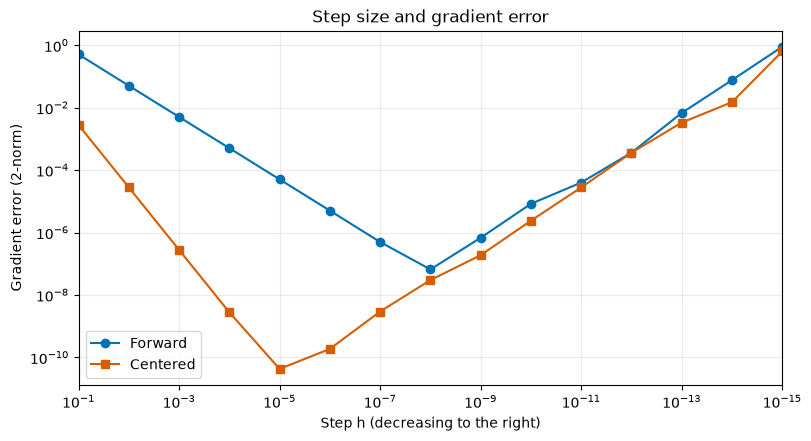

In [18]:
steps = np.logspace(-1, -15, 15)
forward_errors = []
centered_errors = []
# 外层改变步长，内层逐坐标计算前向差分；解析梯度保持不变。
for step in steps:
    forward = np.zeros_like(w)
    base_value = nonlinear_loss(w, X, y)
    for index in range(w.size):
        perturbation = np.zeros_like(w)
        perturbation[index] = step
        forward[index] = (nonlinear_loss(w + perturbation, X, y) - base_value) / step
    # 中心差分沿用已定义的函数，再用相同的二范数汇总两种误差。
    centered = central_gradient(nonlinear_loss, w, step, X, y)
    forward_error = np.linalg.norm(forward - reference)
    centered_error = np.linalg.norm(centered - reference)
    forward_errors.append(forward_error)
    centered_errors.append(centered_error)
    # 本次中心差分误差先从约 2.8e-3 降至 4.3e-11，之后因舍入影响回升。
    print(f"h={step:.0e}，前向误差={forward_error:.3e}，中心误差={centered_error:.3e}")

# 只在完成所有计算后绘图，观察缩小步长何时不再改善精度。
fig, ax = plt.subplots(figsize=(8, 4.3), layout="constrained")
ax.loglog(
    steps, forward_errors, "o-", color="#0072B2", label="Forward", nonpositive="mask"
)
ax.loglog(
    steps, centered_errors, "s-", color="#D55E00", label="Centered", nonpositive="mask"
)
ax.set(
    xlim=(steps[0], steps[-1]),
    xlabel="Step h (decreasing to the right)",
    ylabel="Gradient error (2-norm)",
    title="Step size and gradient error",
)
ax.grid(which="both", alpha=0.25)
ax.legend()
# 缩小步长最初改善近似，过小后误差回升；最佳区间依赖函数、输入尺度和精度。
plt.show()

## 8 解析求导、差分与自动微分的区别

三种方式可以指向同一个数学梯度，但计算过程不同。

| 名称 | 中文名称／含义 | 本章中的对应过程 |
| --- | --- | --- |
| Analytic differentiation | 解析求导 | 先推导 $X^T(XW-Y)$，再代入参数计算 |
| Finite differences | 有限差分 | 扰动输入，比较若干次目标函数值；需要选择步长 |
| Automatic differentiation（AD） | 自动微分 | 沿程序运算的依赖关系，用局部导数和链式法则传递导数 |

自动微分无需用一个小步长近似导数，也不等于先生成完整的符号公式。它仍会受到浮点误差和所用运算求导规则的影响；数学函数本身不可导时，工具约定的返回值不代表普通导数存在。

以 $Z=XW$、$R=Z-Y$、$L=\tfrac12\sum R_{ij}^2$ 为例：先保存前向值，再反向传递 $\nabla_RL=R$、$\nabla_ZL=R$、$\nabla_WL=X^T\nabla_ZL$。下面手写这三步来展示计算图的局部传递机制；它不是通用自动微分框架，也没有安装或调用此类框架。

In [19]:
X = np.array([[1.0, 2.0], [2.0, -1.0], [1.0, 1.0]])
Y = np.array([[1.0, 2.0], [0.0, -1.0], [2.0, 1.0]])
W = np.array([[0.5, 1.0], [-0.5, 0.0]])

# 前向计算：保留每一步的值。
Z = X @ W
R = Z - Y
loss_value = 0.5 * np.sum(R**2)

# 反向计算：这里由我们手写每一步的局部求导规则。
gradient_R = R
gradient_Z = gradient_R
gradient_W = X.T @ gradient_Z
print("前向目标值：", loss_value)  # 9.25。
print("反向传递得到的梯度：\n", gradient_W)  # 预期约为 [[-0.5 5. ] [-6.5 -5. ]]。
# 预期为 True。
print(
    "与解析公式一致：",
    np.allclose(gradient_W, squared_gradient(W, X, Y), atol=1e-12, rtol=0),
)
# 计算中没有差分步长；X.T 来自线性运算对输入参数的链式法则。

前向目标值： 9.25
反向传递得到的梯度：
 [[-0.5  5. ]
 [-6.5 -5. ]]
与解析公式一致： True


## 9 综合应用：平均平方误差加参数惩罚

### 9.1 先明确取平均的范围

对固定 $X\in\mathbb R^{m\times n}$、$Y\in\mathbb R^{m\times q}$ 与参数 $W\in\mathbb R^{n\times q}$，定义

$$J(W)=\frac{1}{2m}\|XW-Y\|_F^2+\frac{\lambda}{2}\|W\|_F^2,\qquad \lambda\geq0.$$

第一项是每条样本的半平方误差取平均，输出各列仍求和；第二项是参数平方范数惩罚。$\lambda$ 是固定实系数。本例数据无单位，只用于教学核对。利用梯度的加法和数乘规则，得到

$$\nabla_WJ=\frac1mX^T(XW-Y)+\lambda W.$$

如果写成对全部 $mq$ 个残差的 mean，就会再除以 $q$；若只改目标函数而不改梯度，检查应能发现差别。下面明确用 sum/m，避免隐藏归约范围。

In [20]:
def regularized_loss(parameters, inputs, targets, penalty):
    residuals = inputs @ parameters - targets
    # residuals 的行是样本、列是输出；这里只除以样本数，不再除以输出数。
    data_term = 0.5 * np.sum(residuals**2) / inputs.shape[0]
    penalty_term = 0.5 * penalty * np.sum(parameters**2)
    return data_term + penalty_term


def regularized_gradient(parameters, inputs, targets, penalty):
    residuals = inputs @ parameters - targets
    # 数据项梯度与参数惩罚梯度相加，结果形状与 parameters 一致。
    return inputs.T @ residuals / inputs.shape[0] + penalty * parameters


X = np.array([[1.0, 2.0], [2.0, -1.0], [1.0, 1.0]])
Y = np.array([[1.0, 2.0], [0.0, -1.0], [2.0, 1.0]])
W = np.array([[0.2, -0.4], [0.7, 0.1]])
penalty = 0.3
G = regularized_gradient(W, X, Y, penalty)
# 差分独立调用目标函数；同时报告绝对误差和按梯度尺度归一化的误差。
G_fd = central_gradient(regularized_loss, W, 1e-5, X, Y, penalty)
error = np.linalg.norm(G_fd - G, ord="fro")
scale = max(1.0, np.linalg.norm(G, ord="fro"))

print("目标值：", regularized_loss(W, X, Y, penalty))  # 预期约为 1.47167。
print("解析梯度：\n", G)  # 预期约为 [[-0.306667 -1.22 ] [ 0.343333 -1.90333]]。
print("差分梯度：\n", G_fd)  # 预期约为 [[-0.306667 -1.22 ] [ 0.343333 -1.90333]]。
print("绝对与尺度化误差：", error, error / scale)  # 本次绝对误差和尺度化误差分别约 3.1e-11、1.3e-11，用量级核对即可。
# 本例梯度约为 [[-0.3067, -1.2200], [0.3433, -1.9033]]。

目标值： 1.4716666666666665
解析梯度：
 [[-0.30666667 -1.22      ]
 [ 0.34333333 -1.90333333]]
差分梯度：
 [[-0.30666667 -1.22      ]
 [ 0.34333333 -1.90333333]]
绝对与尺度化误差： 3.087606583711749e-11 1.3382699467807442e-11


### 9.2 用方向变化核对梯度的实际含义

固定非零方向 $H\in\mathbb R^{n\times q}$ 并令 $\|H\|_F=1$。沿它移动的方向导数为

$$\left.\frac{\mathrm d}{\mathrm dt}J(W+tH)\right|_{t=0}
=\langle G,H\rangle_F=\operatorname{tr}(G^TH).$$

将这个标量与方向中心差分比较，可以核对整个矩阵的线性变化；只检查一个方向可能漏掉与该方向正交的错误，因此这里把它作为逐元素检查的补充。

最后取小扰动 $\Delta W=-\eta G$，$\eta>0$。一阶预测为 $\langle G,\Delta W\rangle_F=-\eta\|G\|_F^2$；有限扰动还含剩余项，应同时计算实际目标差，而不是只看预测的负号。

In [21]:
# 沿用上一单元的目标、X、Y、W、penalty 和 G。
H = np.array([[1.0, -2.0], [0.5, 1.0]])
H = H / np.linalg.norm(H, ord="fro")
h = 1e-5
directional_fd = (
    regularized_loss(W + h * H, X, Y, penalty)
    - regularized_loss(W - h * H, X, Y, penalty)
) / (2 * h)
directional_exact = np.sum(G * H)
print("梯度给出的方向导数：", directional_exact)  # 预期约为 0.160667。
print("方向中心差分：", directional_fd)  # 预期约为 0.160667。
print("二者绝对差：", abs(directional_fd - directional_exact))  # 本次数值约为 4.3e-12。

eta = 0.01
change = -eta * G
old_value = regularized_loss(W, X, Y, penalty)
new_value = regularized_loss(W + change, X, Y, penalty)
linear_prediction = np.sum(G * change)
print("一阶预测的目标变化：", linear_prediction)  # 预期约为 -0.05323。
print("实际目标变化：", new_value - old_value)  # 预期约为 -0.052544。
# 本次小步更新使目标下降；预测与实际之间有二次项差别，不代表任意步长都有效。

梯度给出的方向导数： 0.1606666666666664
方向中心差分： 0.16066666667091667
二者绝对差： 4.250266805172487e-12
一阶预测的目标变化： -0.053229999999999986
实际目标变化： -0.05254396240740711


## 本章小结

（1）梯度始终对应一个标量输出。本章采用列向量梯度；矩阵梯度与独立参数矩阵同形，具体下标对应具体偏导。

（2）内积、平方范数与平方误差都能从元素和求导。迹把元素系数整理成 $\mathrm dF=\operatorname{tr}(G^T\mathrm dW)$，转置与乘法次序要由形状核对。

（3）平方误差的梯度是 $X^T(XW-Y)$；取平均、乘常数、增加惩罚或共享参数，都会改变需要计算的导数。

（4）解析推导、计算图导数传递和有限差分应给出相容的结果，但差分有步长误差。检查多个元素、输入和步长，结合绝对误差与尺度判断。

自查：为什么 $2Ax$ 需要对称条件？为什么单个方向上的梯度检查通过，仍可能漏掉矩阵中某些错误？

## 练习

（1）二次型的对称条件

对 $f(x)=\tfrac12x^TAx+b^Tx$，其中 A、b 由下方给出，先逐元素展开，再写出梯度。在指定输入处比较解析梯度与中心差分。

核对标准：保留非对称矩阵的两个贡献，说明为什么不能直接使用 $Ax+b$。然后把 A 改成 $(A+A^T)/2$，判断函数值与正确梯度是否改变。

In [22]:
A = np.array([[2.0, 3.0], [-1.0, 4.0]])
b = np.array([1.0, -2.0])
x = np.array([0.4, -0.7])
# 补充：定义标量目标与解析梯度，再用 central_gradient 核对。

（2）输出取平均以后，梯度怎么变

定义 $J(W)=\tfrac12\operatorname{mean}((XW-Y)^2)$，其中平方是逐元素运算，mean 对全部残差元素取平均。推导同形梯度，并与只除以样本数 m 的写法比较。

核对标准：目标和梯度使用同一个归约范围；说明两种梯度之间的倍数关系，并通过有限差分发现漏除输出数的错误。

In [23]:
X = np.array([[1.0, 0.0], [1.0, 1.0], [1.0, 2.0]])
Y = np.array([[1.0, -1.0], [2.0, 0.0], [2.5, 1.0]])
W = np.array([[0.3, -0.2], [0.4, 0.1]])
# 补充：写出均值目标、正确梯度与漏掉输出数的梯度，并分别核对。

（3）矩阵元素不再独立

令 $W(s)=\begin{bmatrix}s&2s\\0&1\end{bmatrix}$，$F(W)=\tfrac12\|W-C\|_F^2$，其中 C 固定。先计算无约束矩阵梯度，再通过链式法则求 $\mathrm dF(W(s))/\mathrm ds$。

核对标准：把两个依赖 s 的位置都计入，并保留第二个位置的系数 2。用标量 s 的中心差分验证；说明为什么只扰动 W 的一个元素不对应本题的自由参数变化。

In [24]:
C = np.array([[1.0, -1.0], [2.0, 0.0]])
s = 0.4
h = 1e-5
# 补充：构造 W(s)，手算导数，再用 s+h 和 s-h 的函数值核对。

（4）一个方向通过，是否就够了

设真实梯度 $G=\begin{bmatrix}1&2\\3&4\end{bmatrix}$，某错误实现返回 $G_{\mathrm{wrong}}=G+E$，其中 $E=\begin{bmatrix}0&1\\-1&0\end{bmatrix}$。先用全 1 矩阵归一化得到方向 H，比较两份梯度与 H 的 Frobenius 内积；再选择另一个方向使它们不同。

核对标准：解释误差矩阵与检查方向正交时为什么会漏检，并说明如何用逐坐标或多个方向补充检查。

In [25]:
G = np.array([[1.0, 2.0], [3.0, 4.0]])
E = np.array([[0.0, 1.0], [-1.0, 0.0]])
H = np.ones((2, 2))
H = H / np.linalg.norm(H, ord="fro")
# 补充：比较内积，再构造能检出错误的另一方向。

## 练习提示与解析

以下对应练习（1）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：把交叉项展开，可以看见 A 的两个非对角元素共同贡献。

提示 2：一般公式使用 $(A+A^T)/2$；只有 A 对称时才能直接用 A。

### 练习（1）参考解析

本题 $f(x)=x_1^2+x_1x_2+2x_2^2+x_1-2x_2$，所以列梯度为 $(2x_1+x_2+1,\ x_1+4x_2-2)^T$。代入 $(0.4,-0.7)^T$ 得 $(1.1,-4.4)^T$。

矩阵写法为 $\nabla f=(A+A^T)x/2+b$，而错误写法 $Ax+b$ 会得到 $(-0.3,-5.2)^T$。把 A 换成其对称部分后，函数值与正确梯度都不变，因为反对称部分对 $x^TAx$ 的贡献为零。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Stanford CS229 | [Linear Algebra Review and Reference](https://cs229.stanford.edu/section/cs229-linalg.pdf)：§4.1，第 20–22 页，标量对矩阵的同形梯度、列向量梯度与求导变量；§4.3–4.4，第 23–25 页，线性式、二次型及最小二乘梯度的逐元素推导。 |
| DTU — Petersen 与 Pedersen | [The Matrix Cookbook，2012-11-15 版](https://www2.imm.dtu.dk/pubdb/edoc/imm3274.pdf)：第 8 页的独立元素前提与微分规则；§2.4 式 69、81 的线性式与一般二次型；§2.5 式 100、103、115、119 的迹导数；§2.6–2.8，第 14–15 页的范数求导和结构化矩阵参数。 |
| explained.ai — Parr 与 Howard | [The Matrix Calculus You Need For Deep Learning](https://explained.ai/matrix-calculus/)：Introduction to vector calculus and partial derivatives、Generalization of the Jacobian、The Chain Rules；用于逐元素求导与布局辨析，本文采用列向量梯度。 |
| Deep Learning — 作者提供的教材 | [第 2 章](https://www.deeplearningbook.org/contents/linear_algebra.html) §2.5、§2.10 的 Frobenius 范数与迹性质；[第 4 章](https://www.deeplearningbook.org/contents/numerical.html) §4.3 的方向导数和局部梯度方向，§4.5 式 4.21–4.24 的半平方误差及梯度。 |
| Fundamentals of Numerical Computation — 作者教材 | [§5.5 Convergence of finite differences](https://fncbook.com/fd-converge/)：截断误差定义，§5.5.1 的前向与中心差分，§5.5.2 的舍入与步长竞争。 |
| arXiv — Baydin 等作者论文 | [Automatic Differentiation in Machine Learning: a Survey，v4](https://arxiv.org/html/1502.05767v4)：§2.1–2.2 区分数值、符号求导；§3、§3.2 的运算依赖、局部链式法则与反向传递。 |
| JAX 官方文档 | [Automatic differentiation](https://docs.jax.dev/en/latest/automatic-differentiation.html) §5 Checking against numerical differences：逐参数与方向差分核对。本章仅参考核对思路，不需要安装 JAX。 |
| SciPy 1.18 官方文档 | [scipy.optimize.check_grad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.check_grad.html)：前向差分语义、epsilon、direction 和返回的误差 2 范数。 |
| NumPy 2.5 官方文档 | [numpy.trace](https://numpy.org/doc/stable/reference/generated/numpy.trace.html) 的二维迹；[numpy.linalg.norm](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) 的向量 2 范数与矩阵 fro；[numpy.ndindex](https://numpy.org/doc/stable/reference/generated/numpy.ndindex.html) 的下标遍历；[numpy.zeros_like](https://numpy.org/doc/stable/reference/generated/numpy.zeros_like.html) 的 shape、dtype；[numpy.ravel](https://numpy.org/doc/stable/reference/generated/numpy.ravel.html)、[numpy.reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) 的 C 索引顺序；[numpy.allclose](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html) 的绝对与相对容差条件。 |
| Matplotlib 3.11 官方文档 | [Axes.loglog](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.loglog.html)：双对数坐标与 nonpositive 参数；[pyplot.show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html)：显式显示图形。 |